In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df=pd.read_csv("C:\\Users\\priya\\Downloads\\customer_data.csv",encoding='unicode_escape')

In [12]:
df.shape

(27, 15)

In [13]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           27 non-null     int64  
 1   Cust_name         27 non-null     object 
 2   Product_ID        27 non-null     object 
 3   Gender            27 non-null     object 
 4   Age Group         27 non-null     object 
 5   Age               27 non-null     int64  
 6   Marital_Status    27 non-null     int64  
 7   State             27 non-null     object 
 8   Zone              27 non-null     object 
 9   Occupation        27 non-null     object 
 10  Product_Category  27 non-null     object 
 11  Orders            27 non-null     int64  
 12  Amount            27 non-null     float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 3.3+ KB


In [15]:
df.drop(['Status','unnamed1'],axis=1, inplace=True)

In [16]:
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [17]:
df.dropna(inplace=True)

In [18]:
df['Amount'] = df['Amount'].astype('int')

In [19]:
df['Amount'].dtypes

dtype('int64')

In [20]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [21]:
df.rename(columns={'Marital_Status':'Shaadi'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shaadi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
5,1000589,Raj,P00057943,M,36-45,40,1,Rajasthan,Western,Food Processing,Auto,1,18500
6,1000590,Meera,P00057944,F,18-25,22,0,Kerala,Southern,Healthcare,Electronics,2,8999
7,1000591,Arun,P00057945,M,26-35,30,1,Tamil Nadu,Southern,IT,Electronics,1,45999
8,1000592,Priya,P00057946,F,36-45,38,0,Karnataka,Southern,Govt,Clothing,3,3599
9,1000593,Vikram,P00057947,M,18-25,19,0,Maharashtra,Western,Automobile,Electronics,2,24999


In [22]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,2.700000e+01,27.000000,27.000000,27.000000,27.000000
mean,1.000771e+06,32.777778,0.518519,1.925926,16380.296296
std,5.241133e+02,8.893962,0.509175,0.957799,12536.733852
min,1.000588e+06,16.000000,0.000000,1.000000,599.000000
25%,1.000594e+06,28.000000,0.000000,1.000000,5747.500000
50%,1.000601e+06,32.000000,1.000000,2.000000,15999.000000
75%,1.000608e+06,39.500000,1.000000,2.500000,23929.000000
max,1.002903e+06,49.000000,1.000000,4.000000,45999.000000


In [23]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,27.000000,27.000000,27.000000
mean,32.777778,1.925926,16380.296296
std,8.893962,0.957799,12536.733852
min,16.000000,1.000000,599.000000
25%,28.000000,1.000000,5747.500000
50%,32.000000,2.000000,15999.000000
75%,39.500000,2.500000,23929.000000
max,49.000000,4.000000,45999.000000


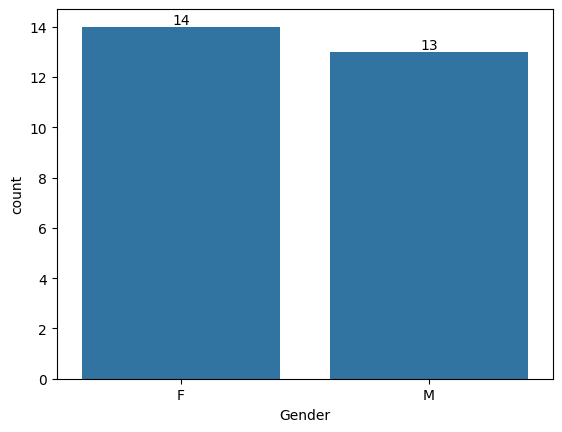

In [24]:
ax = sns.countplot(x = 'Gender',data = df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

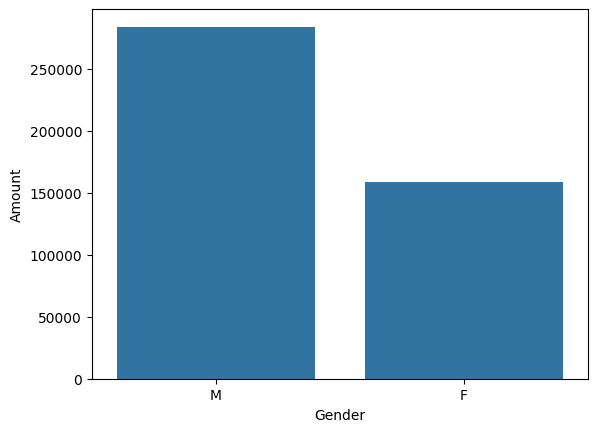

In [25]:
sales_gen = df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(x = 'Gender',y='Amount',data = sales_gen)

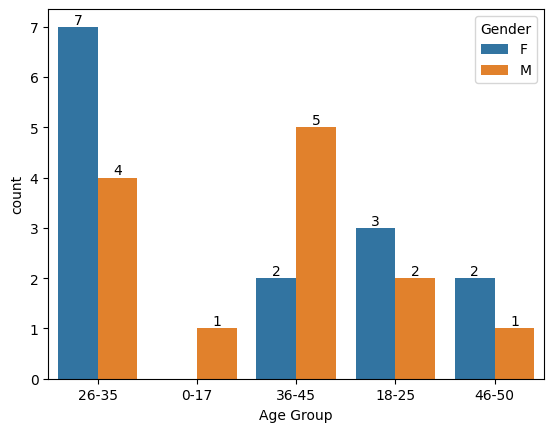

In [26]:
ax = sns.countplot(data = df,x = 'Age Group',hue = 'Gender')
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

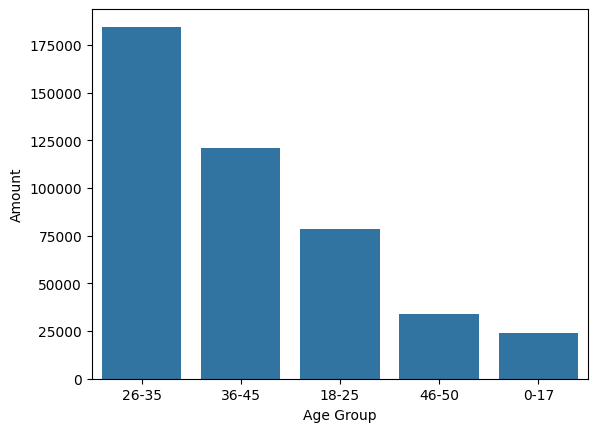

In [27]:
sales_age = df.groupby(['Age Group'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending= False)
sns.barplot(x = 'Age Group',y='Amount',data = sales_age)

<Axes: xlabel='State', ylabel='Orders'>

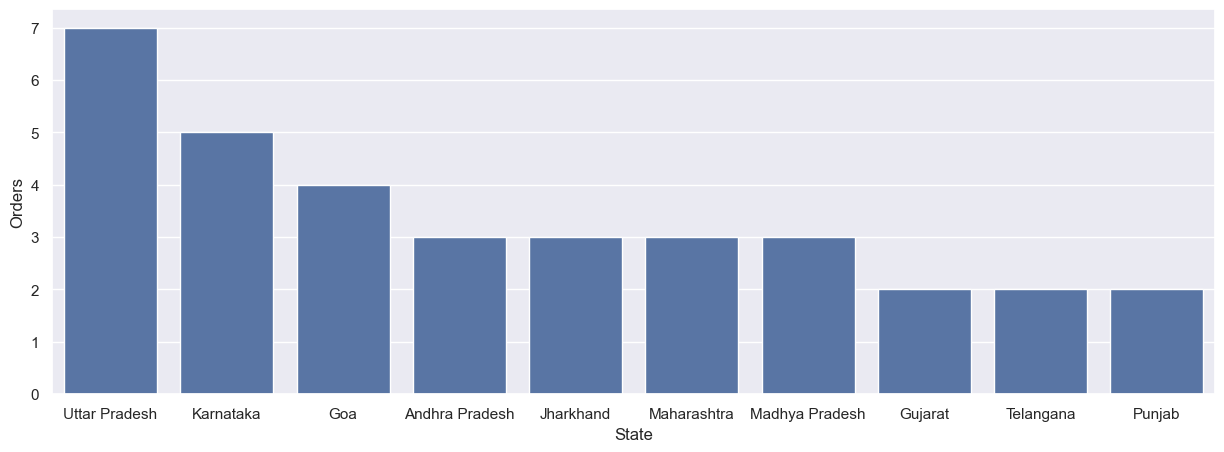

In [28]:
sales_state = df.groupby(['State'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)
sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y='Orders')

<Axes: xlabel='State', ylabel='Amount'>

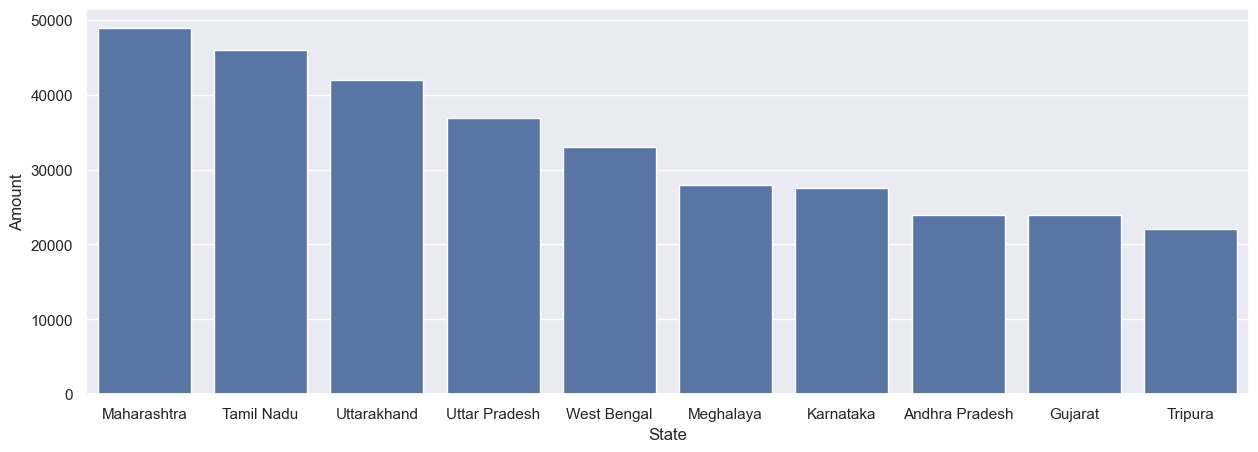

In [29]:
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(15,5 )})
sns.barplot(data = sales_state, x = 'State',y='Amount')

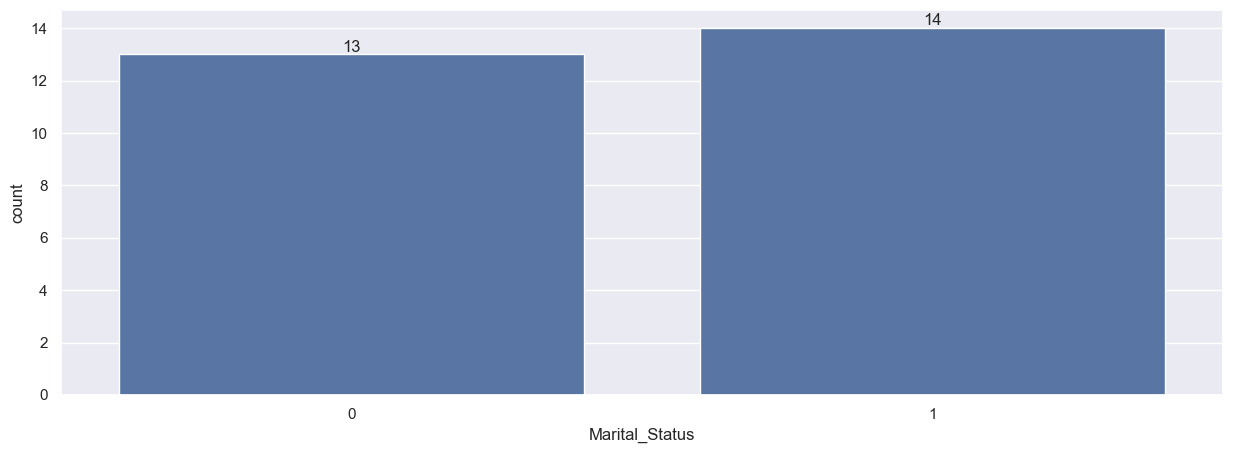

In [30]:
ax = sns.countplot(data = df, x = 'Marital_Status')
sns.set(rc={'figure.figsize':(7,5)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

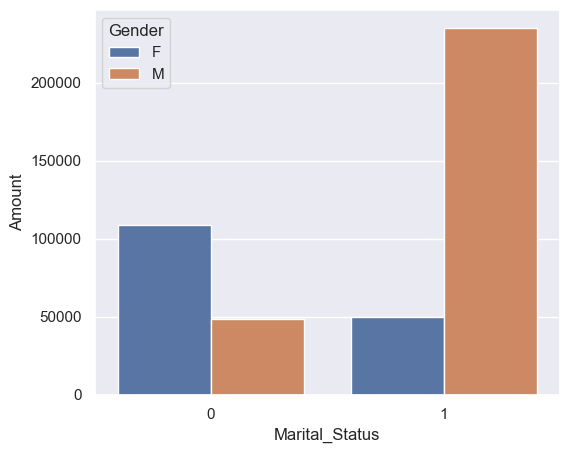

In [32]:
sales_state = df.groupby(['Marital_Status','Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')


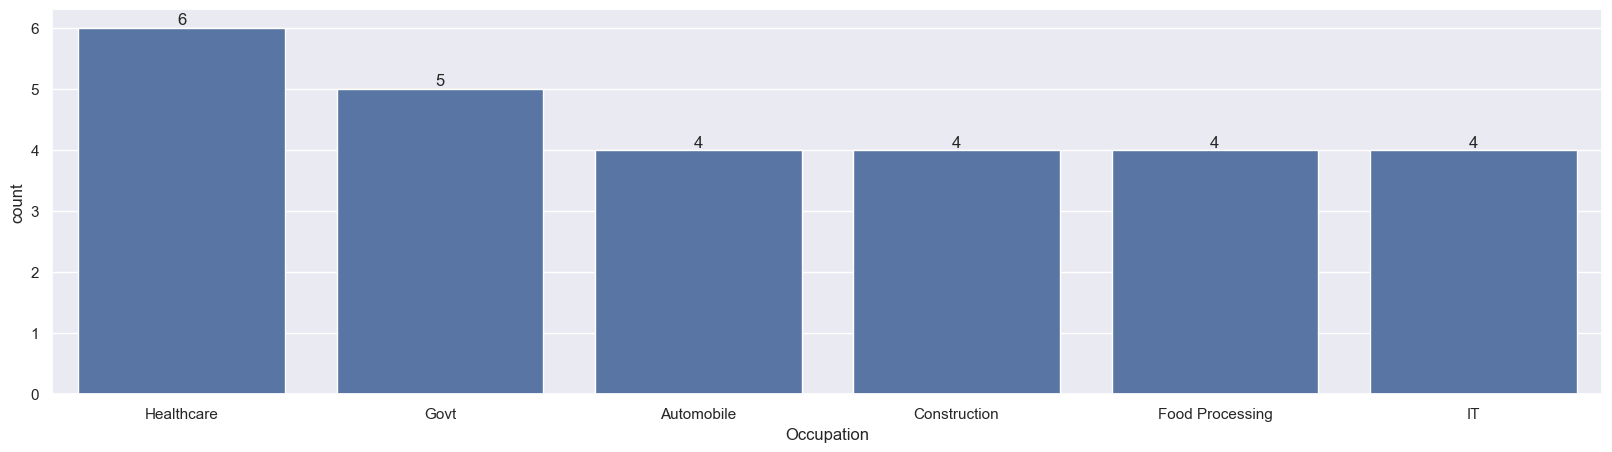

In [39]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation')
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

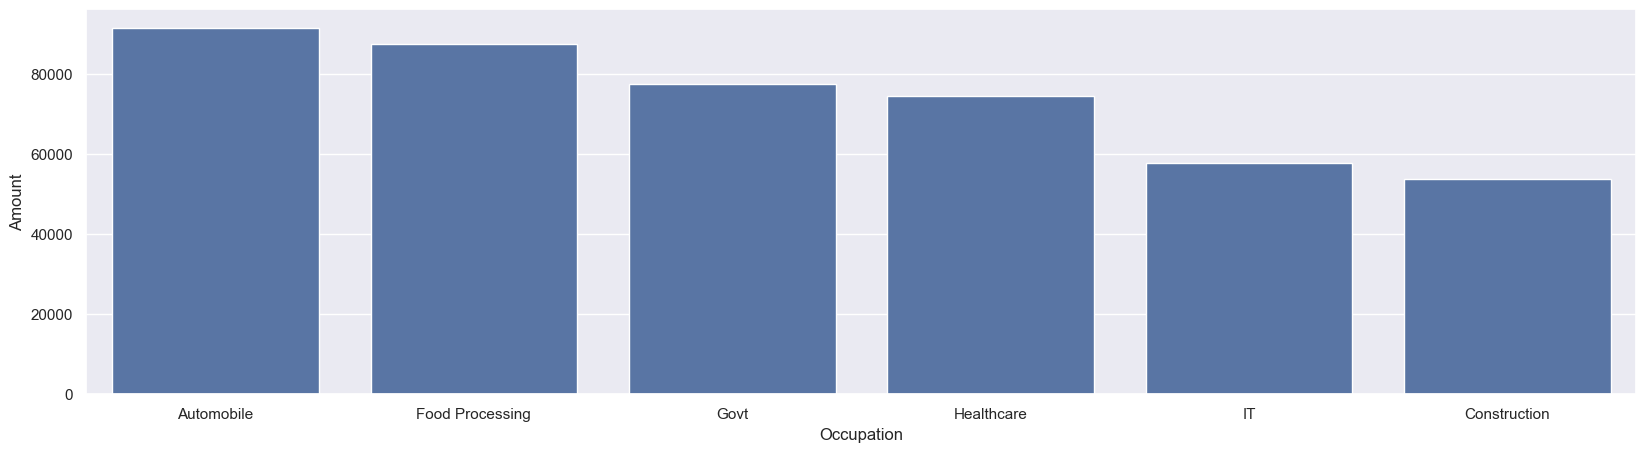

In [40]:
sales_state = df.groupby(['Occupation'], as_index= False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y='Amount')

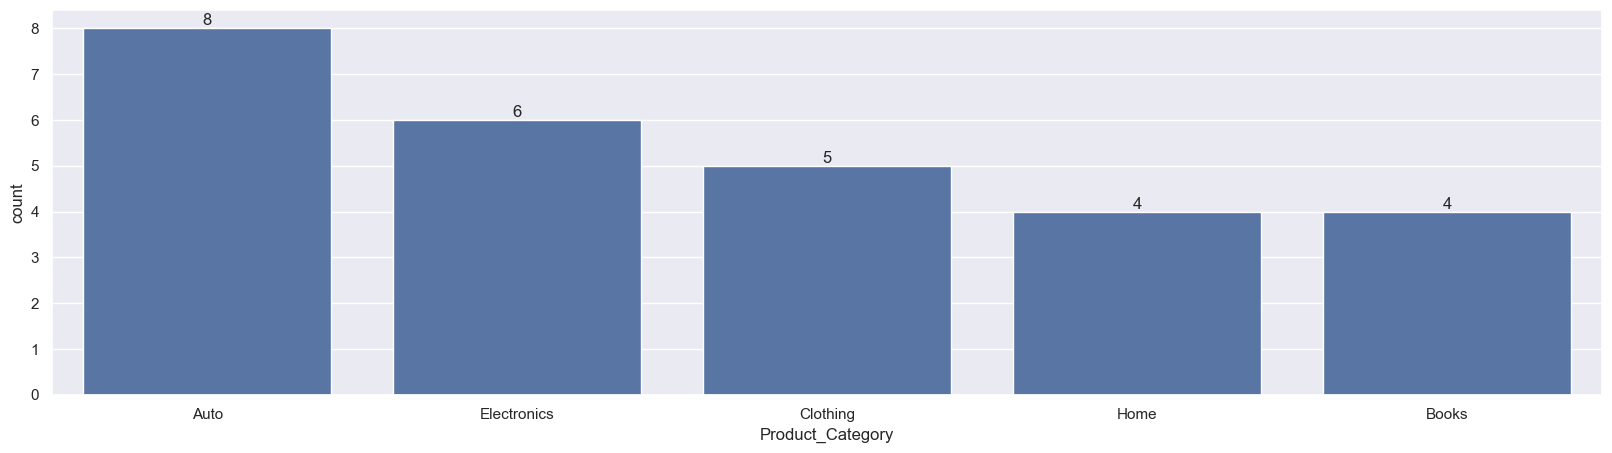

In [41]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Product_Category')
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

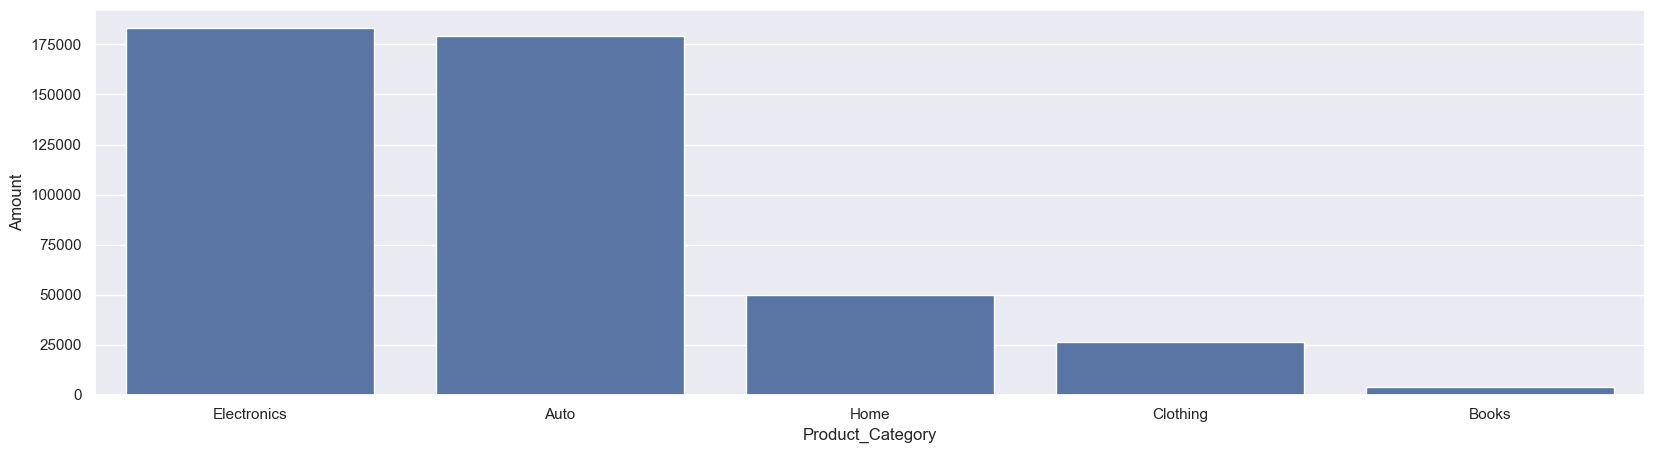

In [42]:
sales_state = df.groupby(['Product_Category'], as_index = False)['Amount'].sum().sort_values(by='Amount',ascending= False).head(10)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y='Amount')

<Axes: xlabel='Product_ID', ylabel='Orders'>

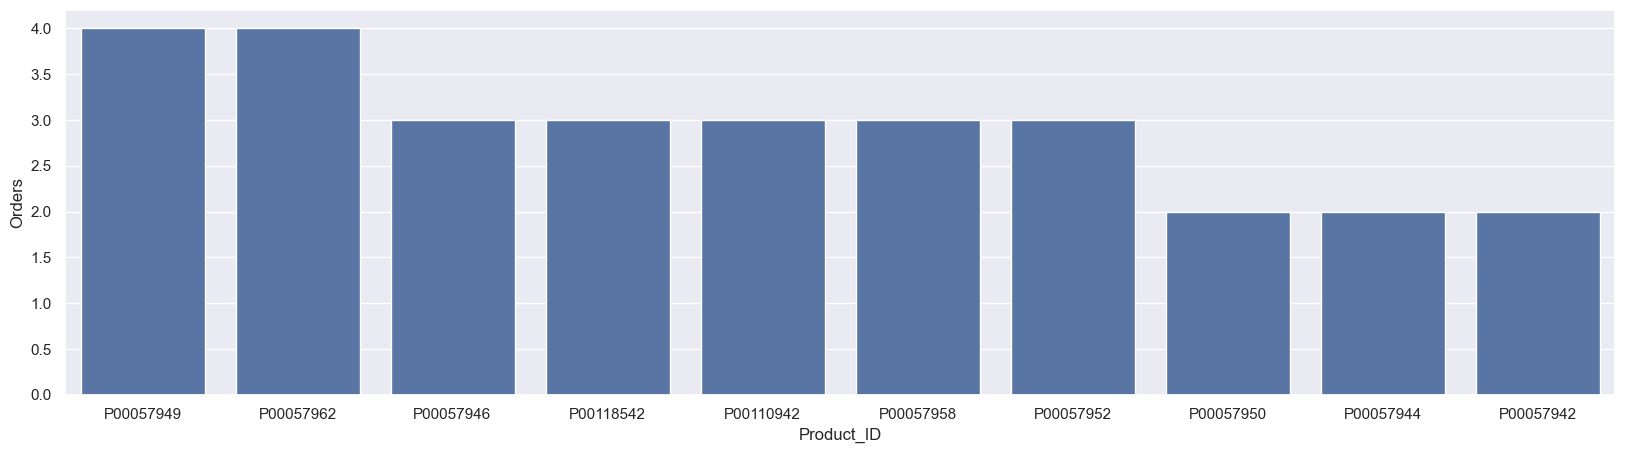

In [43]:
sales_state = df.groupby(['Product_ID'],as_index=False)['Orders'].sum().sort_values(by= 'Orders',ascending= False).head(10)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID',y='Orders')

<Axes: xlabel='Product_ID'>

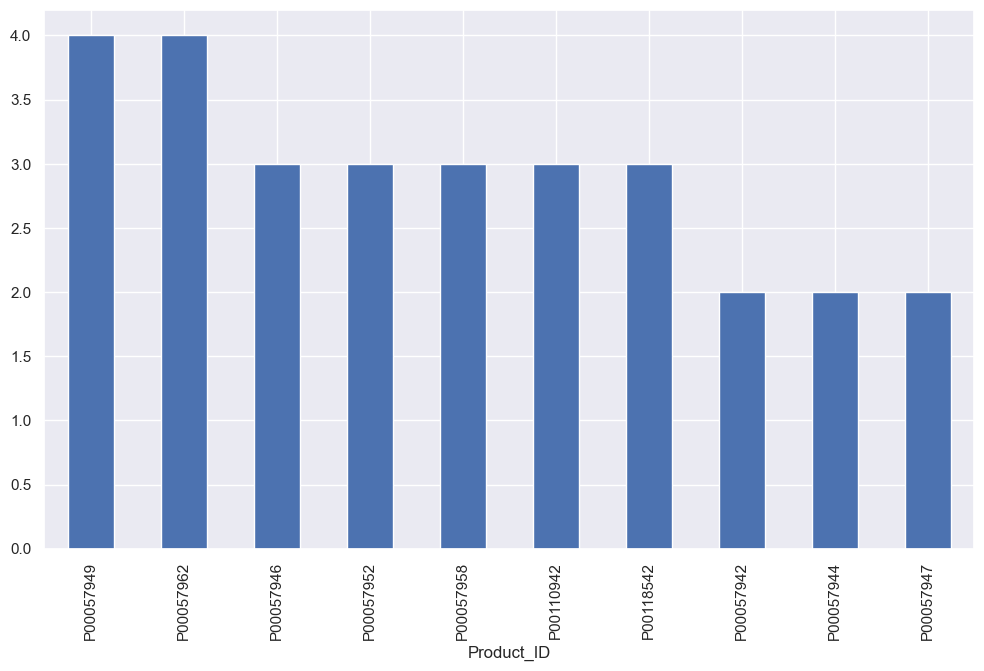

In [ ]:
fig1, ax1 = plt.subplots(figsize=(12,7))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending= False).plot(kind='bar')

In [ ]:
# *Married women age group 26-35 yrs from UP,Maharastra and Karnataka working
# in IT, Healthcare and Aviationare more likely to buy products from Food, 
# Clothing and Electronics category*